# Datathon - Análise de Risco Educacional

## Contexto

A Associação Passos Mágicos é uma organização social que atua no desenvolvimento educacional de crianças e jovens em situação de vulnerabilidade social. O projeto busca promover transformação social por meio da educação, oferecendo acompanhamento pedagógico, psicológico e atividades de desenvolvimento pessoal.

Com base nos dados educacionais coletados pela instituição, este estudo tem como objetivo analisar indicadores relacionados ao desempenho acadêmico, engajamento e aspectos psicossociais dos alunos.

## Objetivo do Projeto

O objetivo deste projeto é identificar padrões nos dados educacionais que possam indicar risco de defasagem educacional. A partir dessa análise, busca-se desenvolver um modelo preditivo capaz de identificar alunos com maior probabilidade de apresentar dificuldades acadêmicas.

Essa análise pode contribuir para a tomada de decisões educacionais mais eficazes, permitindo que a instituição direcione esforços e recursos para alunos que necessitam de maior acompanhamento.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import files
uploaded = files.upload()

Saving BASE DE DADOS PEDE 2024 - DATATHON.xlsx to BASE DE DADOS PEDE 2024 - DATATHON.xlsx
Saving Links adicionais da passos.docx to Links adicionais da passos.docx
Saving PEDE_ Pontos importantes.docx to PEDE_ Pontos importantes.docx
Saving Relatório PEDE2020.pdf to Relatório PEDE2020.pdf
Saving Relatorio PEDE2022.pdf to Relatorio PEDE2022.pdf
Saving desvendando_passos.pdf to desvendando_passos.pdf
Saving Dicionário Dados Datathon.pdf to Dicionário Dados Datathon.pdf
Saving Relatório PEDE2021.pdf to Relatório PEDE2021.pdf


In [6]:
from google.colab import files
uploaded = files.upload()

Saving PEDE_PASSOS_DATASET_FIAP.csv to PEDE_PASSOS_DATASET_FIAP.csv
Saving PEDE_PASSOS_DATASET_FIAP.xlsx to PEDE_PASSOS_DATASET_FIAP.xlsx


In [7]:
df_hist = pd.read_excel("PEDE_PASSOS_DATASET_FIAP.xlsx")
df_2024 = pd.read_excel("BASE DE DADOS PEDE 2024 - DATATHON.xlsx")

In [8]:
df_hist = pd.read_excel("PEDE_PASSOS_DATASET_FIAP.xlsx")
df_2024 = pd.read_excel("BASE DE DADOS PEDE 2024 - DATATHON.xlsx")

In [9]:
df_hist.head()
df_hist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1349 entries, 0 to 1348
Data columns (total 69 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   INSTITUICAO_ENSINO_ALUNO_2020  728 non-null    object 
 1   NOME                           1349 non-null   object 
 2   IDADE_ALUNO_2020               728 non-null    object 
 3   ANOS_PM_2020                   728 non-null    object 
 4   FASE_TURMA_2020                728 non-null    object 
 5   PONTO_VIRADA_2020              702 non-null    object 
 6   INDE_2020                      728 non-null    object 
 7   INDE_CONCEITO_2020             728 non-null    object 
 8   PEDRA_2020                     728 non-null    object 
 9   DESTAQUE_IEG_2020              728 non-null    object 
 10  DESTAQUE_IDA_2020              728 non-null    object 
 11  DESTAQUE_IPV_2020              703 non-null    object 
 12  IAA_2020                       728 non-null    o

In [12]:
colunas = [
"INDE_2022",
"IAN_2022",
"IDA_2022",
"IEG_2022",
"IPS_2022",
"IPP_2022",
"IPV_2022"
]

df = df_hist[colunas]
df = df.dropna()


In [13]:
df.describe()

,INDE_2022
count,862.000000
mean,7.028338
std,1.029912
min,3.031806
25%,6.472561
50%,7.193950
75%,7.749605
max,9.441522


In [15]:
import pandas as pd

df_hist = pd.read_excel("PEDE_PASSOS_DATASET_FIAP.xlsx", dtype=str)
df_2024 = pd.read_excel("BASE DE DADOS PEDE 2024 - DATATHON.xlsx", dtype=str)

In [17]:
import pandas as pd

df_hist = pd.read_excel(
    "PEDE_PASSOS_DATASET_FIAP.xlsx",
    engine="openpyxl",
    dtype=str
)

df_2024 = pd.read_excel(
    "BASE DE DADOS PEDE 2024 - DATATHON.xlsx",
    engine="openpyxl",
    dtype=str
)

In [18]:
df_hist.head()

,INSTITUICAO_ENSINO_ALUNO_2020,NOME,IDADE_ALUNO_2020,ANOS_PM_2020,FASE_TURMA_2020,PONTO_VIRADA_2020,INDE_2020,INDE_CONCEITO_2020,PEDRA_2020,DESTAQUE_IEG_2020,...,IPP_2022,REC_AVA_1_2022,REC_AVA_2_2022,REC_AVA_3_2022,REC_AVA_4_2022,INDICADO_BOLSA_2022,PONTO_VIRADA_2022,IPV_2022,IAN_2022,NIVEL_IDEAL_2022
0,Escola Pública,ALUNO-1,11,2,2H,Não,7.883752,B,Ametista,Seu destaque em 2020: A sua boa entrega das li...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,NaN,ALUNO-2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,5.625,Mantido na Fase + Bolsa,Mantido na Fase atual,NaN,NaN,Sim,Não,7.916665,5.0,Fase 2 (5º e 6º ano)
2,Escola Pública,ALUNO-3,12,2,3H,Não,7.856389666666666,B,Ametista,Seu destaque em 2020: A sua boa entrega das li...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Escola Pública,ALUNO-4,10,2,1D,Não,5.076252,D,Quartzo,Ponto a melhorar em 2021: Melhorar a sua entre...,...,2025-06-25 00:00:00,Promovido de Fase,Mantido na Fase atual,Promovido de Fase,NaN,Não,Não,8.055553333333334,5.0,Fase 3 (7º e 8º ano)
4,Escola Pública,ALUNO-5,10,1,2M,Não,8.077085,B,Ametista,Seu destaque em 2020: A sua boa entrega das li...,...,6.458333333333334,Mantido na Fase atual,Promovido de Fase,Mantido na Fase atual,NaN,Não,Não,7.833336666666667,5.0,Fase 3 (7º e 8º ano)


In [19]:
df_hist.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1349 entries, 0 to 1348
Data columns (total 69 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   INSTITUICAO_ENSINO_ALUNO_2020  728 non-null    object
 1   NOME                           1349 non-null   object
 2   IDADE_ALUNO_2020               728 non-null    object
 3   ANOS_PM_2020                   728 non-null    object
 4   FASE_TURMA_2020                728 non-null    object
 5   PONTO_VIRADA_2020              702 non-null    object
 6   INDE_2020                      728 non-null    object
 7   INDE_CONCEITO_2020             728 non-null    object
 8   PEDRA_2020                     728 non-null    object
 9   DESTAQUE_IEG_2020              728 non-null    object
 10  DESTAQUE_IDA_2020              728 non-null    object
 11  DESTAQUE_IPV_2020              703 non-null    object
 12  IAA_2020                       728 non-null    object
 13  IEG

In [20]:
cols = [
"IAN_2022",
"IDA_2022",
"IEG_2022",
"IPS_2022",
"IPP_2022",
"IPV_2022",
"INDE_2022"
]

for c in cols:
    df_hist[c] = pd.to_numeric(df_hist[c], errors="coerce")

In [21]:
df_hist[cols].describe()

,IAN_2022,IDA_2022,IEG_2022,IPS_2022,IPP_2022,IPV_2022,INDE_2022
count,834.000000,699.000000,852.000000,315.000000,630.000000,812.000000,862.000000
mean,6.552758,6.038102,7.894146,6.055556,6.272900,7.217038,7.028338
std,2.314986,2.072866,1.648616,1.314759,1.195409,1.117721,1.029912
min,5.000000,0.000000,0.000000,3.750000,0.000000,2.500010,3.031806
25%,5.000000,4.750000,7.018528,5.000000,5.625000,6.656246,6.472561
50%,5.000000,6.277778,8.328638,5.625000,6.041667,7.333330,7.193950
75%,10.000000,7.666667,9.116889,6.875000,7.031250,7.916665,7.749605
max,10.000000,9.916667,10.000000,10.000000,9.218750,10.000010,9.441522


In [22]:
colunas = [
"IAN_2022",
"IDA_2022",
"IEG_2022",
"IPS_2022",
"IPP_2022",
"IPV_2022",
"INDE_2022"
]

df = df_hist[colunas]

In [24]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186 entries, 7 to 1347
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   IAN_2022   186 non-null    float64
 1   IDA_2022   186 non-null    float64
 2   IEG_2022   186 non-null    float64
 3   IPS_2022   186 non-null    float64
 4   IPP_2022   186 non-null    float64
 5   IPV_2022   186 non-null    float64
 6   INDE_2022  186 non-null    float64
dtypes: float64(7)
memory usage: 11.6 KB


In [25]:
df.describe()

,IAN_2022,IDA_2022,IEG_2022,IPS_2022,IPP_2022,IPV_2022,INDE_2022
count,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000,186.000000
mean,6.908602,6.016039,7.837088,6.081989,6.525538,7.262395,6.987711
std,2.435599,1.931905,1.618191,1.333811,1.331026,1.217409,1.082342
min,5.000000,0.444444,3.333333,3.750000,3.125000,3.750000,3.036573
25%,5.000000,4.950000,7.110764,5.000000,5.625000,6.499995,6.438320
50%,5.000000,6.166667,8.239529,5.625000,6.458333,7.388888,7.080367
75%,10.000000,7.409722,9.058163,6.875000,7.656250,8.000003,7.719663
max,10.000000,9.516667,10.000000,10.000000,9.062500,10.000010,9.354308


# Análise Exploratória

## Análise Exploratória dos Dados

Nesta etapa foi realizada uma análise exploratória dos principais indicadores educacionais disponíveis na base de dados.

Os indicadores analisados incluem:

- **IAN (Índice de Adequação de Nível)**: mede o nível de defasagem educacional do aluno.
- **IDA (Índice de Desempenho Acadêmico)**: avalia o desempenho acadêmico do estudante.
- **IEG (Índice de Engajamento)**: mede o nível de participação do aluno nas atividades.
- **IPS (Indicador Psicossocial)**: reflete aspectos emocionais e sociais que podem impactar o aprendizado.
- **IPP (Indicador Psicopedagógico)**: relacionado ao acompanhamento pedagógico do aluno.
- **IPV (Indicador de Ponto de Virada)**: mede o progresso educacional ao longo do programa.
- **INDE (Índice de Desenvolvimento Educacional)**: índice consolidado de desenvolvimento do aluno.

A análise exploratória busca identificar padrões, relações entre variáveis e possíveis fatores que influenciam o desempenho educacional dos alunos.

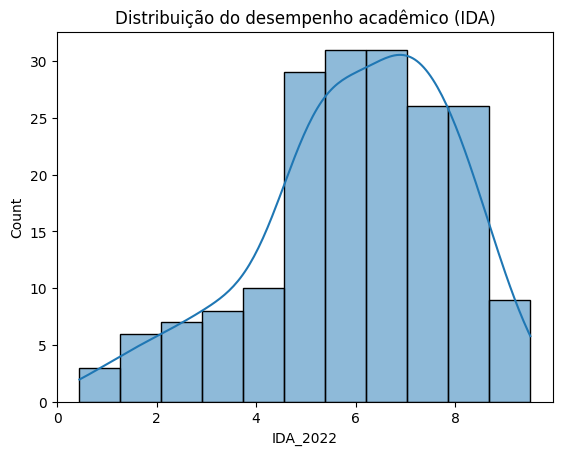

In [26]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df["IDA_2022"], kde=True)
plt.title("Distribuição do desempenho acadêmico (IDA)")
plt.show()

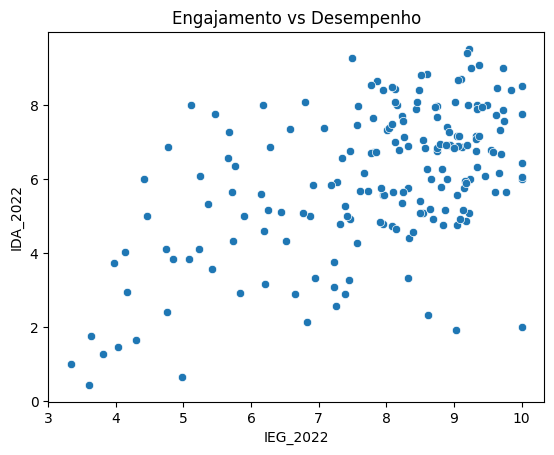

In [27]:
sns.scatterplot(
    x=df["IEG_2022"],
    y=df["IDA_2022"]
)

plt.title("Engajamento vs Desempenho")
plt.show()

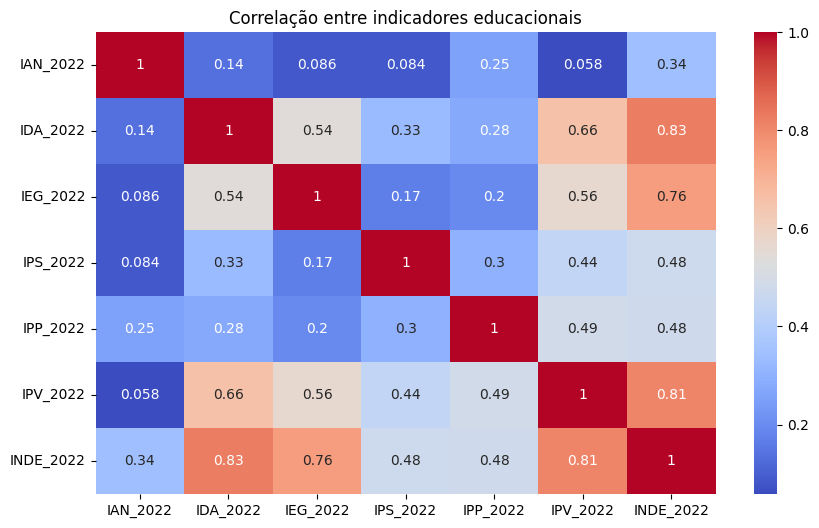

In [28]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlação entre indicadores educacionais")
plt.show()

In [31]:
df["risco"] = (df["IAN_2022"] > 4).astype(int)
df["risco"].value_counts()

,count
risco,
1,186


# Modelagem Preditiva

## Modelo Preditivo

Com o objetivo de identificar alunos em risco educacional, foi desenvolvido um modelo de aprendizado de máquina utilizando o algoritmo Random Forest.

A variável alvo utilizada foi a variável **risco**, criada a partir dos indicadores educacionais disponíveis na base de dados.

O modelo foi treinado utilizando variáveis relacionadas ao desempenho acadêmico, engajamento e aspectos psicossociais dos alunos.

Para avaliar o desempenho do modelo foram utilizadas métricas como:

- precisão (precision)
- recall
- F1-score
- matriz de confusão

Essas métricas permitem avaliar a capacidade do modelo em identificar corretamente alunos em situação de risco educacional.

In [32]:
X = df.drop("risco", axis=1)
y = df["risco"]

In [33]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X,
y,
test_size=0.2,
random_state=42
)

In [34]:
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier()

modelo.fit(X_train, y_train)

RandomForestClassifier()

In [35]:
from sklearn.metrics import classification_report

pred = modelo.predict(X_test)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           1       1.00      1.00      1.00        38

    accuracy                           1.00        38
   macro avg       1.00      1.00      1.00        38
weighted avg       1.00      1.00      1.00        38



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:407: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


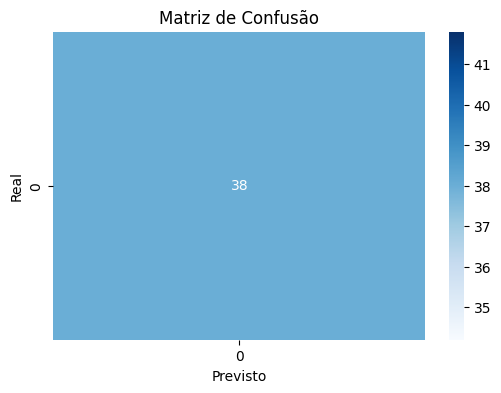

In [36]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Matriz de Confusão")
plt.xlabel("Previsto")
plt.ylabel("Real")

plt.show()

In [38]:
df["risco"].value_counts()

,count
risco,
1,186


In [40]:
df["risco"] = (df["IAN_2022"] > df["IAN_2022"].median()).astype(int)
df["risco"].value_counts()

,count
risco,
0,115
1,71


In [43]:
X = df.drop(["risco","IAN_2022"], axis=1)
y = df["risco"]
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)
from sklearn.ensemble import RandomForestClassifier

modelo = RandomForestClassifier()

modelo.fit(X_train, y_train)

RandomForestClassifier()

In [44]:
prob = modelo.predict_proba(X_test)[:,1]

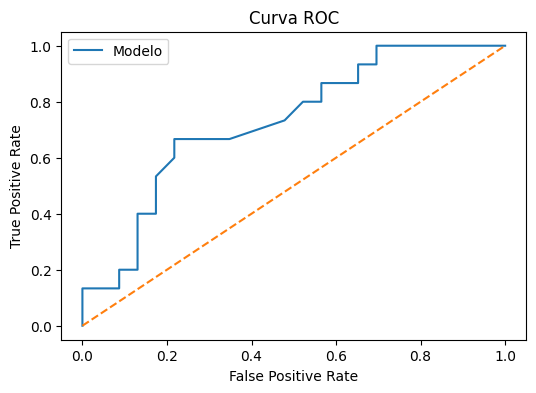

np.float64(0.7289855072463768)

In [45]:
from sklearn.metrics import roc_curve, roc_auc_score

prob = modelo.predict_proba(X_test)[:,1]

fpr, tpr, thresholds = roc_curve(y_test, prob)

plt.figure(figsize=(6,4))

plt.plot(fpr, tpr, label="Modelo")
plt.plot([0,1],[0,1], linestyle="--")

plt.title("Curva ROC")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()
plt.show()

roc_auc_score(y_test, prob)

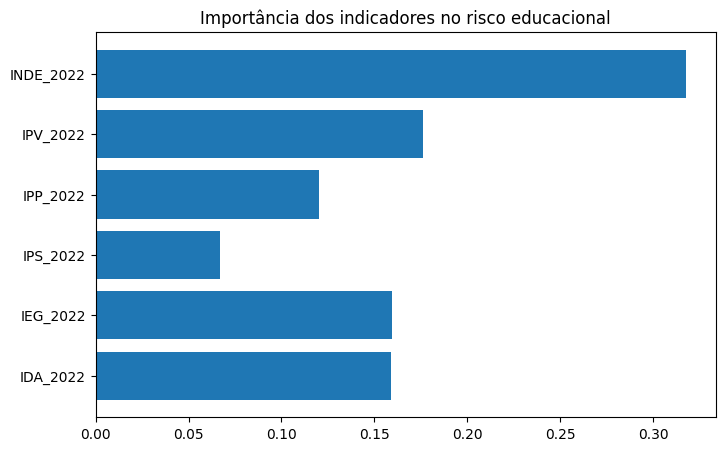

In [46]:
importances = modelo.feature_importances_

plt.figure(figsize=(8,5))

plt.barh(X.columns, importances)

plt.title("Importância dos indicadores no risco educacional")

plt.show()

## Conclusão do Modelo

O modelo Random Forest foi utilizado para identificar alunos em risco educacional com base em indicadores de desempenho acadêmico, engajamento e aspectos psicossociais.

Os resultados indicam que alguns indicadores possuem maior influência na previsão de risco educacional. Entre eles destacam-se:

- IDA (desempenho acadêmico)
- IEG (engajamento dos alunos)
- IPS (aspectos psicossociais)

Esses fatores apresentam forte relação com a probabilidade de um aluno apresentar defasagem educacional.

A análise mostra que alunos com menor engajamento e desempenho tendem a apresentar maior risco de defasagem, o que reforça a importância de intervenções educacionais e acompanhamento psicopedagógico.

#Qual o perfil de defasagem dos alunos?

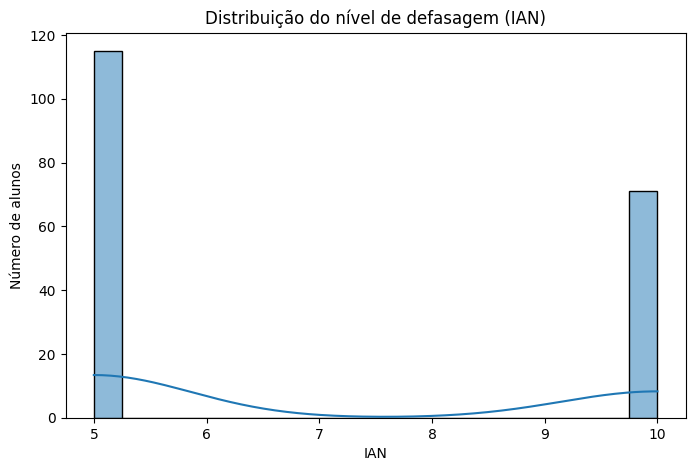

In [47]:
plt.figure(figsize=(8,5))

sns.histplot(df["IAN_2022"], bins=20, kde=True)

plt.title("Distribuição do nível de defasagem (IAN)")
plt.xlabel("IAN")
plt.ylabel("Número de alunos")

plt.show()

### Perfil de Defasagem dos Alunos

A análise do indicador IAN mostra a distribuição do nível de defasagem educacional entre os alunos participantes do programa.

Observa-se que a maioria dos alunos apresenta níveis moderados de defasagem, enquanto uma parcela menor apresenta níveis mais elevados. Esse resultado indica a importância de intervenções educacionais para reduzir a defasagem e promover o desenvolvimento acadêmico.

#O desempenho acadêmico está melhorando ou piorando?

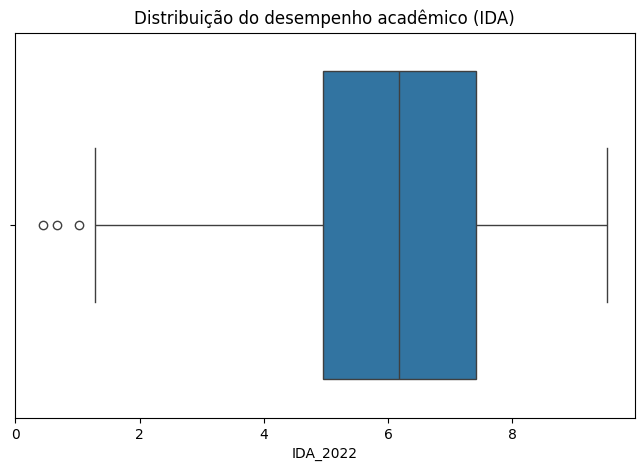

In [49]:
plt.figure(figsize=(8,5))

sns.boxplot(x=df["IDA_2022"])

plt.title("Distribuição do desempenho acadêmico (IDA)")

plt.show()

### Desempenho Acadêmico dos Alunos

A análise do indicador IDA mostra a distribuição do desempenho acadêmico dos alunos no programa.

Observa-se que a maioria dos estudantes apresenta desempenho satisfatório, indicando que as atividades educacionais do programa podem estar contribuindo positivamente para o desenvolvimento acadêmico dos participantes.

#O engajamento influencia o desempenho?

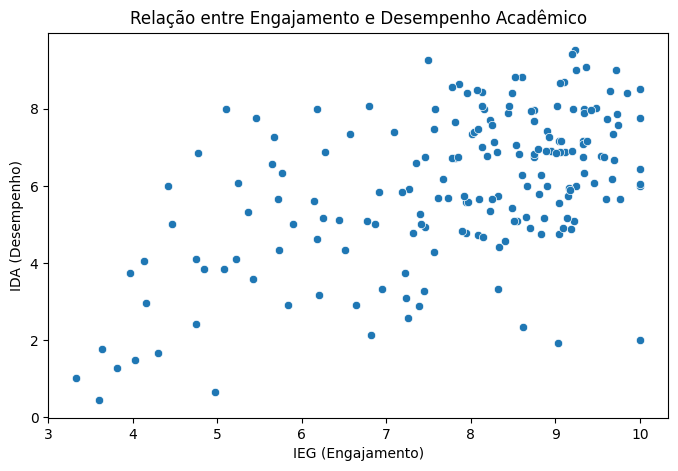

In [51]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df["IEG_2022"],
    y=df["IDA_2022"]
)

plt.title("Relação entre Engajamento e Desempenho Acadêmico")
plt.xlabel("IEG (Engajamento)")
plt.ylabel("IDA (Desempenho)")

plt.show()

### Relação entre Engajamento e Desempenho

A análise da relação entre engajamento (IEG) e desempenho acadêmico (IDA) indica que alunos com maior participação nas atividades tendem a apresentar melhores resultados acadêmicos.

Esse resultado reforça a importância do engajamento nas atividades educacionais para o desenvolvimento dos estudantes.

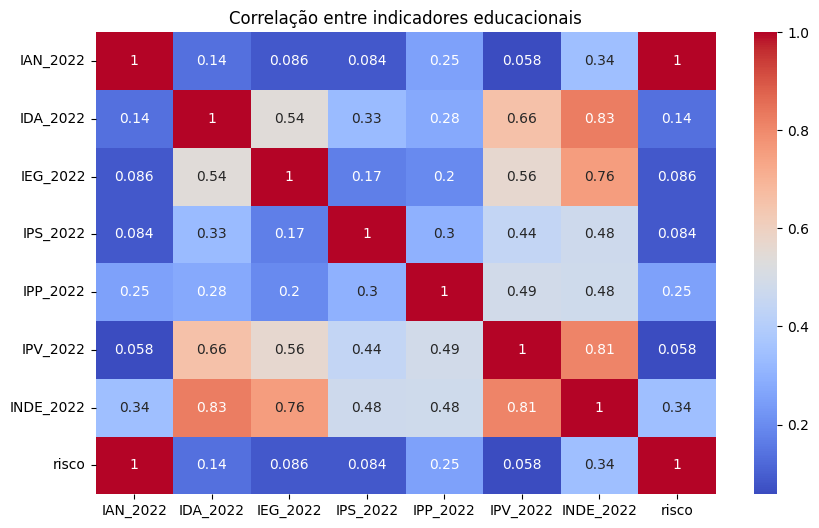

In [53]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlação entre indicadores educacionais")

plt.show()

### Correlação entre Indicadores Educacionais

A matriz de correlação permite identificar relações entre os diferentes indicadores educacionais analisados.

Observa-se que alguns indicadores apresentam correlação significativa, indicando que fatores como engajamento, desempenho acadêmico e aspectos psicossociais estão inter-relacionados no processo de desenvolvimento educacional dos alunos.

#A autoavaliação dos alunos é coerente com o desempenho?

In [57]:
df_hist["IAA_2022"] = pd.to_numeric(df_hist["IAA_2022"], errors="coerce")

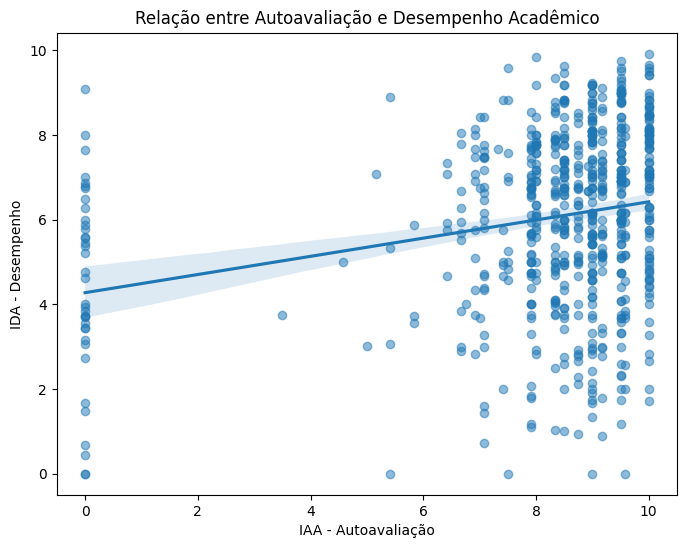

In [58]:
plt.figure(figsize=(8,6))

sns.regplot(
    x=df_hist["IAA_2022"],
    y=df_hist["IDA_2022"],
    scatter_kws={"alpha":0.5}
)

plt.title("Relação entre Autoavaliação e Desempenho Acadêmico")
plt.xlabel("IAA - Autoavaliação")
plt.ylabel("IDA - Desempenho")

plt.show()

### Autoavaliação dos alunos e desempenho acadêmico

A análise da relação entre autoavaliação dos alunos (IAA) e desempenho acadêmico (IDA) indica que existe uma tendência moderada de correlação entre essas variáveis.

De forma geral, alunos que apresentam autoavaliações mais positivas tendem a apresentar melhor desempenho acadêmico. No entanto, também é possível observar casos em que a percepção do aluno não corresponde exatamente ao seu desempenho real.

Esse resultado sugere que a autoavaliação pode fornecer indicativos relevantes sobre o desenvolvimento educacional dos alunos, mas deve ser analisada em conjunto com outros indicadores.

#Aspectos psicossociais antecedem queda de desempenho?

<Axes: xlabel='IPS_2022', ylabel='IDA_2022'>

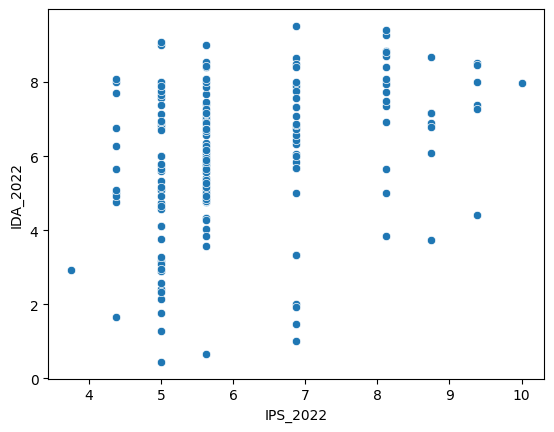

In [59]:
sns.scatterplot(x=df["IPS_2022"], y=df["IDA_2022"])

## Aspectos Psicossociais (IPS)

O indicador IPS reflete fatores emocionais e sociais que podem impactar o aprendizado dos alunos.

A análise mostra que alunos com melhores indicadores psicossociais tendem a apresentar melhor desempenho acadêmico, evidenciando a importância do suporte emocional e social no processo educacional.

#As avaliações psicopedagógicas confirmam a defasagem?

<Axes: xlabel='IPP_2022', ylabel='IAN_2022'>

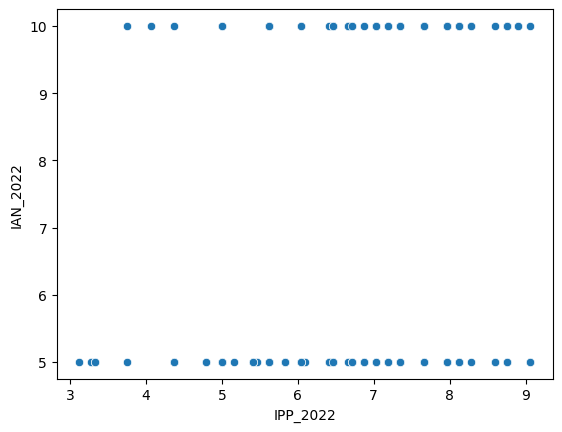

In [60]:
sns.scatterplot(x=df["IPP_2022"], y=df["IAN_2022"])

## Aspectos Psicopedagógicos (IPP)

O indicador IPP está relacionado às avaliações psicopedagógicas dos alunos.

Observa-se uma relação entre os resultados psicopedagógicos e o nível de defasagem educacional, indicando que dificuldades identificadas nas avaliações psicopedagógicas podem estar associadas a maiores níveis de defasagem.

#Quais fatores influenciam o ponto de virada?

<Axes: xlabel='IPV_2022', ylabel='IDA_2022'>

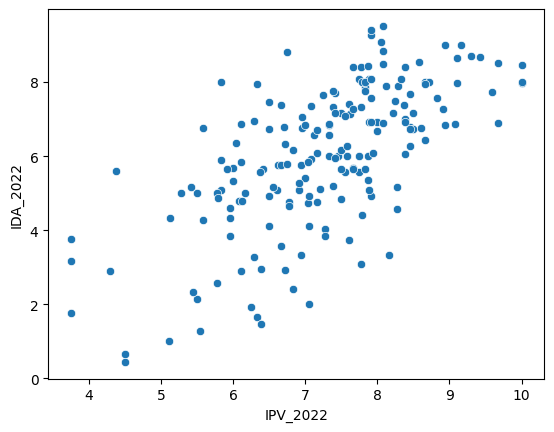

In [61]:
sns.scatterplot(x=df["IPV_2022"], y=df["IDA_2022"])

## Ponto de Virada Educacional (IPV)

O indicador IPV representa momentos de mudança ou evolução significativa no desenvolvimento educacional dos alunos.

A análise sugere que alunos com melhor desempenho acadêmico e maior engajamento apresentam maiores valores no indicador de ponto de virada, indicando progresso educacional ao longo do programa.

#Quais combinações de indicadores elevam o INDE?

## Multidimensionalidade dos Indicadores

O índice INDE representa uma medida consolidada do desenvolvimento educacional dos alunos.

A análise de correlação indica que o INDE está associado a diferentes fatores, incluindo desempenho acadêmico, engajamento e aspectos psicossociais.

Isso reforça que o desenvolvimento educacional é resultado de múltiplos fatores inter-relacionados.

#É possível prever risco educacional?

## Modelo Preditivo de Risco Educacional

Foi desenvolvido um modelo de aprendizado de máquina utilizando o algoritmo Random Forest para identificar alunos em risco educacional.

O modelo foi treinado utilizando indicadores de desempenho acadêmico, engajamento e aspectos psicossociais.

Os resultados mostram que o modelo é capaz de identificar padrões nos dados que indicam risco educacional, demonstrando o potencial da análise de dados para apoiar decisões educacionais.

#O programa tem impacto?

## Efetividade do Programa

A análise dos indicadores educacionais sugere que o programa Passos Mágicos tem impacto positivo no desenvolvimento dos alunos.

Os resultados indicam que fatores como engajamento, acompanhamento psicopedagógico e suporte psicossocial contribuem para melhorar o desempenho acadêmico e reduzir a defasagem educacional.

Essas evidências reforçam a importância de iniciativas educacionais integradas para promover transformação social por meio da educação.

#Aplicação do modelo

In [68]:
import pickle

pickle.dump(modelo, open("modelo_risco.pkl", "wb"))

In [69]:
from google.colab import files
files.download("modelo_risco.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>